In [ ]:
# Поместите в переменную names_list список со строками имён
# Отберите из них только те, где wealth принимает значение 'medium, а возраст составляет больше 35.
# Добавьте в исследуемый нами датафрэйм df колонку older_than_30, в которой будет информация превышает ли значение переменной возраста 30 лет или нет (булево значение)
# Получите число уникальных значений для каждой колонки и присвойте её переменной unique_num.
#  Проведите inner join датафрейма data с df из предыдущего шага, объединив их по колонке client_id
# Вернемся к данным по поездкам на такси. На этот раз – из Перу, с рейтингами водителей, пассажиров, координатами, и парой других деталей. Загрузите датасет, используя ; в качестве разделителя. Также укажите, что столбцы start_at, end_at, arrived_at нужно прочитать как даты.
# Проверьте, с какой платформы было сделано больше всего заказов.  В ответе укажите значение в %, округлённое до целого.
# Агрегируйте данные и постройте барчарт, где по оси x будет расположено название платформы (source), а по оси y – количество заказов (абсолютные значения).
# Используйте sns.countplot и проверьте, какой тип поездки (icon) встречался чаще всего.
# С помощью sns.countplot и параметра hue визуализируйте распределение переменной end_state
# Проверим, как распределены оценки водителей (driver_score).


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
names = 'Name1 Surname1, Name2 Surname2, Name3 Surname3, Name4 Surname4'

name_list = names.split(',')
name_list

['Name1 Surname1', ' Name2 Surname2', ' Name3 Surname3', ' Name4 Surname4']

In [3]:
df_1 = pd.DataFrame({
    'client_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'sex': ['F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M'],
    'wealth': ['high', 'medium', 'low', 'medium', 'high',
               'low', 'medium', 'high', 'low', 'medium'],
    'age': [25, 41, 19, 37, 56, 28, 45, 33, 22, 39]
})

df_1.dtypes

client_id    int64
sex            str
wealth         str
age          int64
dtype: object

In [4]:
df_query = df_1.query('wealth == "medium" and age > 35')
print(df_query)

   client_id sex  wealth  age
1          2   M  medium   41
3          4   M  medium   37
6          7   F  medium   45
9         10   M  medium   39


In [5]:
df_1['older_than_30'] = df_1.age > 30
print(df_1)
# lambda x: x >30 ???

   client_id sex  wealth  age  older_than_30
0          1   F    high   25          False
1          2   M  medium   41           True
2          3   F     low   19          False
3          4   M  medium   37           True
4          5   F    high   56           True
5          6   M     low   28          False
6          7   F  medium   45           True
7          8   M    high   33           True
8          9   F     low   22          False
9         10   M  medium   39           True


In [6]:
unique_num = df_1.nunique

print(unique_num)

<bound method DataFrame.nunique of    client_id sex  wealth  age  older_than_30
0          1   F    high   25          False
1          2   M  medium   41           True
2          3   F     low   19          False
3          4   M  medium   37           True
4          5   F    high   56           True
5          6   M     low   28          False
6          7   F  medium   45           True
7          8   M    high   33           True
8          9   F     low   22          False
9         10   M  medium   39           True>


In [9]:
data = pd.DataFrame({
    'client_id': [1, 2, 3, 5, 6, 8, 10, 11],
    'salary': [75000, 52000, 31000, 99000, 47000, 88000, 65000, 43000],
    'city': ['Москва', 'Казань', 'Самара', 'Сочи',
             'Пермь', 'Москва', 'Тула', 'Уфа']
})

print(data)

   client_id  salary    city
0          1   75000  Москва
1          2   52000  Казань
2          3   31000  Самара
3          5   99000    Сочи
4          6   47000   Пермь
5          8   88000  Москва
6         10   65000    Тула
7         11   43000     Уфа


In [10]:
df_1_with_data = df_1.merge(data, on = 'client_id', how = 'inner')

print(df_1_with_data)

   client_id sex  wealth  age  older_than_30  salary    city
0          1   F    high   25          False   75000  Москва
1          2   M  medium   41           True   52000  Казань
2          3   F     low   19          False   31000  Самара
3          5   F    high   56           True   99000    Сочи
4          6   M     low   28          False   47000   Пермь
5          8   M    high   33           True   88000  Москва
6         10   M  medium   39           True   65000    Тула


In [11]:
companies = pd.DataFrame({
    'company': ['Google', 'Google', 'Google',
                'Apple', 'Apple',
                'Yandex', 'Yandex', 'Yandex',
                'VK', 'VK',
                'Ozon', 'Ozon'],
    'income': [120, 180, 150,
               200, 230,
               90, 100, 110,
               70, 80,
               130, 140]
})

companies.to_csv('hw_3_dataframe_companies.csv', sep = ';', index=False)

In [12]:
#функция, которая возвращает агрегированный датафрейм
def read_n_agg(path):
    return pd.read_csv(path, sep=';') \
    .groupby('company') \
    .agg({'income': 'mean'})

print(read_n_agg('hw_3_dataframe_companies.csv'))

         income
company        
Apple     215.0
Google    150.0
Ozon      135.0
VK         75.0
Yandex    100.0


In [13]:
taxi = pd.read_csv('C:/Work/Analytics/taxi_peru.csv', sep=';', encoding= 'windows-1251', parse_dates= ['start_at','end_at','arrived_at'])
taxi.columns

Index(['journey_id', 'user_id', 'driver_id', 'taxi_id', 'icon', 'start_type',
       'start_at', 'start_lat', 'start_lon', 'end_at', 'end_lat', 'end_lon',
       'end_state', 'driver_start_lon', 'arrived_at', 'source', 'driver_score',
       'rider_score'],
      dtype='str')

In [14]:
print(taxi.head(10))

   journey_id  user_id  driver_id  taxi_id       icon start_type  \
0           1     1048        234       45        car   reserved   
1           2     1005        205       52        car   reserved   
2           3     1040        200       35  motorbike       asap   
3           4     1010        231       52        car       asap   
4           5     1029        225       44        car   reserved   
5           6     1001        208       39        car       asap   
6           7     1048        204       44        car       asap   
7           8     1086        209       33        car       asap   
8           9     1021        237       34        car       asap   
9          10     1065        235       18        car       asap   

             start_at  start_lat  start_lon              end_at    end_lat  \
0 2021-05-03 09:11:00 -11.842417 -77.043378 2021-05-03 09:24:00 -11.808567   
1 2021-05-20 20:31:00 -11.998962 -77.147362 2021-05-20 21:14:00 -11.975758   
2 2021-05-14 21:1

In [15]:
#taxi_source = taxi.groupby('source')['user_id'].count().sort_values(ascending=False)

# с какой платформы было сделано больше всего заказов.
taxi_source = taxi['source'].value_counts(normalize=True).mul(100).round(0).astype('int64')
print(taxi_source)

source
Android    53
iPhone     33
Web        14
Name: proportion, dtype: int64


<Axes: xlabel='source', ylabel='count'>

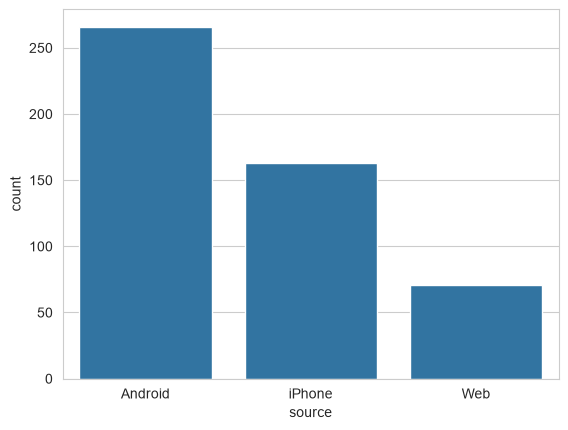

In [16]:
# Агрегируйте данные и постройте барчарт, где по оси x будет
# расположено название платформы (source),
# а по оси y – количество заказов (абсолютные значения)

#taxi_source_barplot = taxi.groupby('source').agg({'user_id': "count"}) \
#    .rename(columns={'user_id': "count"}) \
#    .sort_values('count')

#sns.barplot(
#    data=taxi_source,
#    x='source',
#    y='count'
#)

taxi_source = taxi['source'].value_counts().reset_index()
sns.barplot(
    data=taxi_source,
    x='source',
    y='count'
)


<Axes: xlabel='icon', ylabel='count'>

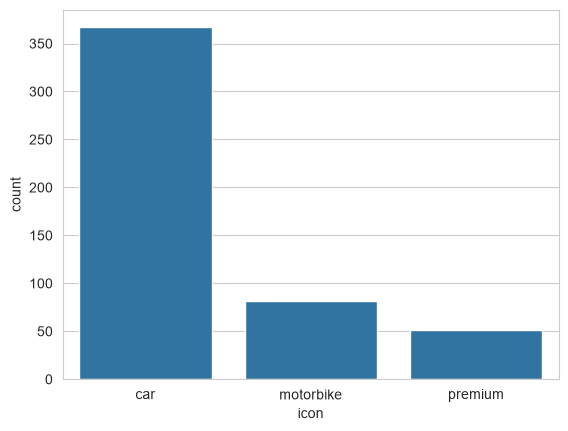

In [17]:
# какой тип поездки (icon) встречается чаще всего

#taxi_icon = taxi['icon'].value_counts().reset_index()

sns.countplot(
    data=taxi,
    x='icon',
)


<Axes: xlabel='source', ylabel='count'>

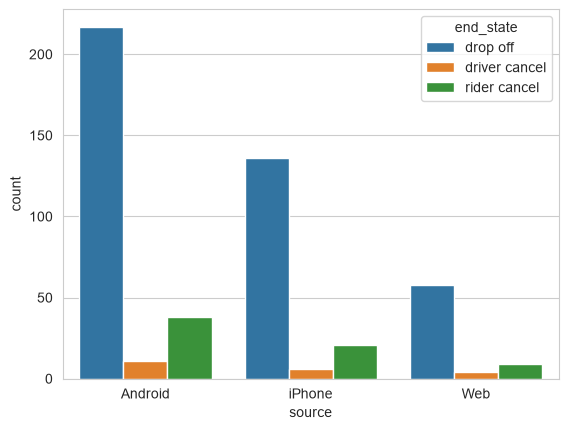

In [18]:
sns.countplot(x = taxi.source, hue = taxi.end_state)

In [19]:
# распределение оценки водителей

driver_score_counts = taxi.driver_score.value_counts(normalize=True) \
    .mul(100).round(2).reset_index() \
    .rename(columns={'proportion': 'percentage'}) \
    .sort_values('driver_score', ascending = False)

print(driver_score_counts)

   driver_score  percentage
0             5        76.6
1             4        13.6
2             3         5.8
3             2         2.6
4             1         0.8
5             0         0.6


In [20]:
taxi.columns

Index(['journey_id', 'user_id', 'driver_id', 'taxi_id', 'icon', 'start_type',
       'start_at', 'start_lat', 'start_lon', 'end_at', 'end_lat', 'end_lon',
       'end_state', 'driver_start_lon', 'arrived_at', 'source', 'driver_score',
       'rider_score'],
      dtype='str')